# NB13a — Layer-by-Layer Constellation Analysis & Arditi Direction Validation

**Story:** How do task-conditioned behavioral representations form across the depth of a language model — and where does Arditi's refusal direction fit in this picture?

## Three Acts
- **Act 1 — Formation (Section 1–2):** Task constellations crystallize layer-by-layer. Early layers are input-dominated. Mid-layers show distinct task clusters. Late layers reveal the final common pathway — or show persistent divergence.
- **Act 2 — Crystallization (Section 3–4):** Within each task, the refusal vs. non-refusal decision commits at a task-specific layer. Staggering across tasks is evidence of task-conditioned processing, not a single shared circuit.
- **Act 3 — Arditi Validation (Section 5–6):** Is there a universal refusal direction across tasks? We measure when task-specific refusal directions converge — and whether that convergence fully explains Arditi's effectiveness, or leaves a systematic gap.

**Output:** 6 publication-quality figures (PDF, 300 DPI) + printed numeric summaries with interpretations.

**Compute:** ~5 min total | Embedding-only — no model inference required.

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA as PCA_sk
from itertools import combinations
import warnings, os, json

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        12,
    'axes.titlesize':   13,
    'axes.labelsize':   12,
    'legend.fontsize':  10,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'font.family':      'serif',
    'lines.linewidth':  2.0,
})

TASK_COLORS = {
    'sentiment_analysis': '#E74C3C',
    'translate':          '#3498DB',
    'rephrase':           '#F39C12',
    'rag_qa':             '#27AE60',
    'cryptanalysis':      '#9B59B6',
}

def fmt_layer(lname):
    return lname.replace('_input_norm', '').replace('layer_', 'L')

print('✓ Setup complete (ACL 2-col format, PCA-based, no umap required)')


✓ Setup complete (ACL 2-col format, PCA-based, no umap required)


In [2]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('./embeddings',       exist_ok=True)
os.makedirs('./arditi_artefacts', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/* arditi_artefacts/

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


In [3]:
def to_np(d):
    return {
        k: (v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor)
            else np.array([e.float().numpy().astype(np.float32) for e in v]))
        for k, v in d.items()
    }

embeddings_dir = './embeddings/'
csv_df         = pd.read_csv(os.path.join(embeddings_dir,
                    sorted([f for f in os.listdir(embeddings_dir) if f.endswith('.csv')])[-1]))
torch_data           = torch.load(csv_df['torch_path'].iloc[0])
embeddings_np        = to_np(torch_data['embeddings'])
texts                = torch_data['texts']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

ALL_TASKS   = sorted(np.unique(intended_task_labels).tolist())
N_SAMPLES   = len(texts)
LAYER_NAMES = [f'layer_{l}_input_norm' for l in range(32)
               if f'layer_{l}_input_norm' in embeddings_np]
N_LAYERS    = len(LAYER_NAMES)

print(f'{N_SAMPLES} samples | {N_LAYERS} layers | {len(ALL_TASKS)} tasks')
print(f'Tasks: {ALL_TASKS}')

270 samples | 31 layers | 5 tasks
Tasks: ['cryptanalysis', 'rag_qa', 'rephrase', 'sentiment_analysis', 'translate']


In [4]:
# ── Canonical behavioral mask definitions ─────────────────────
# Two-mask design (consistent with NB8):
#   HARMLESS_ANSWERED_MASK (~157 wide): benign task INTENT that was answered
#   DIRECTION_HA_MASK (~30 strict):    benign_instruction TEXT TYPE — for direction computation only

BENIGN_TASKS  = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
refusing_mask = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
answered_mask = refusal_labels == 'direct_answer'
harmful_mask  = text_type_labels == 'harmful_instruction'
benign_mask   = np.isin(intended_task_labels, BENIGN_TASKS)

OVER_REFUSAL_MASK      = benign_mask  & refusing_mask          # n≈48
REFUSED_HARMFUL_MASK   = harmful_mask & refusing_mask          # n≈25
HARMLESS_ANSWERED_MASK = benign_mask  & answered_mask          # n≈157  (wide, for viz)
DIRECTION_HA_MASK      = (text_type_labels == 'benign_instruction') & answered_mask  # ~30 (strict, for directions)

TARGET_MASK = (
    ((response_labels == 'cautious') | (response_labels == 'not_harmful')) &
    answered_mask
)

binary_refusal = np.where(refusing_mask, 'refused', 'answered')

beh_labels = np.full(N_SAMPLES, 'other', dtype=object)
beh_labels[REFUSED_HARMFUL_MASK]   = 'refused_harmful'
beh_labels[OVER_REFUSAL_MASK]      = 'over_refusal'
beh_labels[HARMLESS_ANSWERED_MASK] = 'harmless_answered'

TASKS_WITH_OR = [t for t in ALL_TASKS
                 if ((intended_task_labels == t) & OVER_REFUSAL_MASK).sum() >= 3]

try:
    with open('arditi_artefacts/direction_metadata.json') as f:
        BEST_LAYER = json.load(f)['best_layer']
except Exception:
    BEST_LAYER = 'layer_12_input_norm'

print('=== MASK DISTRIBUTION ===')
print(f'  Over-refusal (OR):         {OVER_REFUSAL_MASK.sum():>4d}')
print(f'  Refused-harmful (RH):      {REFUSED_HARMFUL_MASK.sum():>4d}')
print(f'  Harmless-answered (wide):  {HARMLESS_ANSWERED_MASK.sum():>4d}')
print(f'  Direction-HA (strict):     {DIRECTION_HA_MASK.sum():>4d}')
print(f'  Tasks with OR ≥3:          {TASKS_WITH_OR}')
print(f'  Best layer (from NB8):     {BEST_LAYER}')
print()
print(f'  {"Task":<22} {"Total":>6} {"OR":>5} {"RH":>5} {"HA_wide":>8} {"HA_strict":>10}')
for task in ALL_TASKS:
    tm = intended_task_labels == task
    print(f'  {task:<22} {tm.sum():>6} '
          f'{(tm & OVER_REFUSAL_MASK).sum():>5} '
          f'{(tm & REFUSED_HARMFUL_MASK).sum():>5} '
          f'{(tm & HARMLESS_ANSWERED_MASK).sum():>8} '
          f'{(tm & DIRECTION_HA_MASK).sum():>10}')


=== MASK DISTRIBUTION ===
  Over-refusal (OR):           48
  Refused-harmful (RH):        25
  Harmless-answered (wide):   157
  Direction-HA (strict):       30
  Tasks with OR ≥3:          ['sentiment_analysis', 'translate']
  Best layer (from NB8):     layer_17_input_norm

  Task                    Total    OR    RH  HA_wide  HA_strict
  cryptanalysis              60     0     0       60          0
  rag_qa                     30     0     0       30          0
  rephrase                   65     0     8        0          7
  sentiment_analysis         55    20     7       35         15
  translate                  60    28    10       32          8


In [5]:
# ============================================================
# PRE-COMPUTATION — run once (~1-2 min, PCA only, no UMAP)
# ============================================================
print('Pre-computing all metrics across 32 layers...\n')

# ── 1. PCA(2) + inter-task silhouette per layer ───────────────
pca2_per_layer     = {}   # lname -> fitted PCA object
emb2d_per_layer    = {}   # lname -> (N, 2)
task_sil_per_layer = {}   # lname -> inter-task silhouette (cosine)

for i, lname in enumerate(LAYER_NAMES):
    emb = embeddings_np[lname]
    pca = PCA_sk(n_components=2, random_state=42)
    emb2d_per_layer[lname] = pca.fit_transform(emb)
    pca2_per_layer[lname]  = pca
    try:
        task_sil_per_layer[lname] = float(silhouette_score(emb, intended_task_labels, metric='cosine'))
    except Exception:
        task_sil_per_layer[lname] = np.nan
    if i % 8 == 0:
        print(f'  L{i:02d}: inter-task silhouette = {task_sil_per_layer[lname]:.3f}')

# ── 2. Behavioral silhouette: OR vs HA (wide) across all layers
beh_sil_per_layer = {}
or_ha_mask = OVER_REFUSAL_MASK | HARMLESS_ANSWERED_MASK
beh_sil_labels = np.where(OVER_REFUSAL_MASK[or_ha_mask], 'or', 'ha')
for lname in LAYER_NAMES:
    try:
        beh_sil_per_layer[lname] = float(
            silhouette_score(embeddings_np[lname][or_ha_mask], beh_sil_labels, metric='cosine'))
    except Exception:
        beh_sil_per_layer[lname] = np.nan
print('Behavioral silhouette (OR vs HA) done.')

# ── 3. Layer profile: inter-centroid distance, spread, sep ratio
inter_centroid_dist = {}
intra_task_spread   = {}
separation_ratio    = {}
centroid_matrices   = {}
task_centroids_all  = {}

for lname in LAYER_NAMES:
    emb   = embeddings_np[lname]
    cents = {t: emb[intended_task_labels == t].mean(0) for t in ALL_TASKS}
    task_centroids_all[lname] = cents
    pairwise, dmat = [], np.zeros((len(ALL_TASKS), len(ALL_TASKS)))
    for ii, ti in enumerate(ALL_TASKS):
        for jj, tj in enumerate(ALL_TASKS):
            d = float(np.linalg.norm(cents[ti] - cents[tj]))
            dmat[ii, jj] = d
            if ii < jj:
                pairwise.append(d)
    inter_centroid_dist[lname] = float(np.mean(pairwise))
    centroid_matrices[lname]   = dmat
    spreads = []
    for t in ALL_TASKS:
        t_emb = emb[intended_task_labels == t]
        spreads.extend(np.linalg.norm(t_emb - cents[t], axis=1).tolist())
    intra_task_spread[lname] = float(np.mean(spreads))
    separation_ratio[lname]  = inter_centroid_dist[lname] / (intra_task_spread[lname] + 1e-8)
print('Layer profile metrics done.')

# ── 4. Within-task refusal crystallization silhouette ─────────
cryst_sil = {}
for lname in LAYER_NAMES:
    emb = embeddings_np[lname]
    for task in ALL_TASKS:
        mask  = intended_task_labels == task
        t_emb = emb[mask]
        t_bin = binary_refusal[mask]
        if (t_bin == 'refused').sum() < 2 or (t_bin == 'answered').sum() < 2:
            cryst_sil[(task, lname)] = np.nan
            continue
        try:
            cryst_sil[(task, lname)] = float(silhouette_score(t_emb, t_bin, metric='euclidean'))
        except Exception:
            cryst_sil[(task, lname)] = np.nan
print('Crystallization silhouettes done.')

# ── 5. Per-task refusal directions (uses DIRECTION_HA_MASK strict)
task_dirs       = {}
VALID_DIR_TASKS = []
for task in ALL_TASKS:
    n_r = (REFUSED_HARMFUL_MASK & (intended_task_labels == task)).sum()
    n_h = (DIRECTION_HA_MASK    & (intended_task_labels == task)).sum()
    if n_r >= 3 and n_h >= 3:
        VALID_DIR_TASKS.append(task)
        tr = REFUSED_HARMFUL_MASK & (intended_task_labels == task)
        th = DIRECTION_HA_MASK    & (intended_task_labels == task)
        for lname in LAYER_NAMES:
            emb = embeddings_np[lname]
            d = emb[tr].mean(0) - emb[th].mean(0)
            task_dirs[(task, lname)] = d / (np.linalg.norm(d) + 1e-8)
print(f'Per-task refusal directions: {VALID_DIR_TASKS}')

# ── 6. Load Arditi per-layer candidate directions ──────────────
arditi_dirs = {}
try:
    raw = torch.load('arditi_artefacts/candidate_directions.pt')
    for k, v in raw.items():
        d = v.numpy().astype(np.float32) if isinstance(v, torch.Tensor) else np.array(v, dtype=np.float32)
        arditi_dirs[k] = d / (np.linalg.norm(d) + 1e-8)
    print(f'Arditi directions loaded: {len(arditi_dirs)} layers')
except Exception as e:
    print(f'Warning: Arditi directions not available ({e}); will compute on-the-fly')

# ── 7. Cross-task direction similarity + Arditi alignment ──────
dir_pairs      = list(combinations(VALID_DIR_TASKS, 2))
pair_sims      = {p: [] for p in dir_pairs}
arditi_align   = {t: [] for t in VALID_DIR_TASKS}
mean_cross_sim = []

if len(VALID_DIR_TASKS) >= 2:
    for lname in LAYER_NAMES:
        for t1, t2 in dir_pairs:
            if (t1, lname) in task_dirs and (t2, lname) in task_dirs:
                pair_sims[(t1, t2)].append(float(np.dot(task_dirs[(t1, lname)], task_dirs[(t2, lname)])))
            else:
                pair_sims[(t1, t2)].append(np.nan)
        for t in VALID_DIR_TASKS:
            if (t, lname) in task_dirs and lname in arditi_dirs:
                arditi_align[t].append(float(np.dot(task_dirs[(t, lname)], arditi_dirs[lname])))
            else:
                arditi_align[t].append(np.nan)
    mean_cross_sim = [float(np.nanmean([pair_sims[p][i] for p in dir_pairs])) for i in range(N_LAYERS)]
else:
    mean_cross_sim = [np.nan] * N_LAYERS

sep_vals = [separation_ratio[l]    for l in LAYER_NAMES]
sil_vals = [task_sil_per_layer[l]  for l in LAYER_NAMES]
beh_vals = [beh_sil_per_layer[l]   for l in LAYER_NAMES]

peak_inter = int(np.nanargmax(sil_vals))
peak_beh   = int(np.nanargmax(beh_vals))

print(f'\n=== KEY NUMBERS ===')
print(f'  Inter-task silhouette peak: {sil_vals[peak_inter]:.4f} at L{peak_inter:02d}')
print(f'  Behavioral silhouette peak: {beh_vals[peak_beh]:.4f} at L{peak_beh:02d}')
print(f'  Separation ratio peak:      {max(sep_vals):.3f} at L{int(np.argmax(sep_vals)):02d}')
intra_vals  = [intra_task_spread[l]   for l in LAYER_NAMES]
inter_vals  = [inter_centroid_dist[l] for l in LAYER_NAMES]
print('\nAll pre-computations complete.')


Pre-computing all metrics across 32 layers...

  L00: inter-task silhouette = 0.000
  L08: inter-task silhouette = 0.407
  L16: inter-task silhouette = 0.439
  L24: inter-task silhouette = 0.393
Behavioral silhouette (OR vs HA) done.
Layer profile metrics done.
Crystallization silhouettes done.
Per-task refusal directions: ['rephrase', 'sentiment_analysis', 'translate']
Arditi directions loaded: 32 layers

=== KEY NUMBERS ===
  Inter-task silhouette peak: 0.4538 at L12
  Behavioral silhouette peak: 0.1698 at L22
  Separation ratio peak:      2.380 at L01

All pre-computations complete.


---
## Figure 0 — 2D PCA Representation: Why Global Steering Cannot Fix Over-Refusal

**The core visual argument of the paper:**
- Colour = task identity → task clusters are well-separated at L12
- ▲ over-refusal samples sit **inside** their own task cluster (not between RH and HA)
- Black arrow = Arditi global direction (separates RH from HA — task-agnostic)
- Coloured arrows = per-task OR direction (HA centroid → OR centroid — short, task-specific, within-cluster)

**Key insight:** No global direction can selectively reach the OR samples without also suppressing the HA samples in the same cluster region.


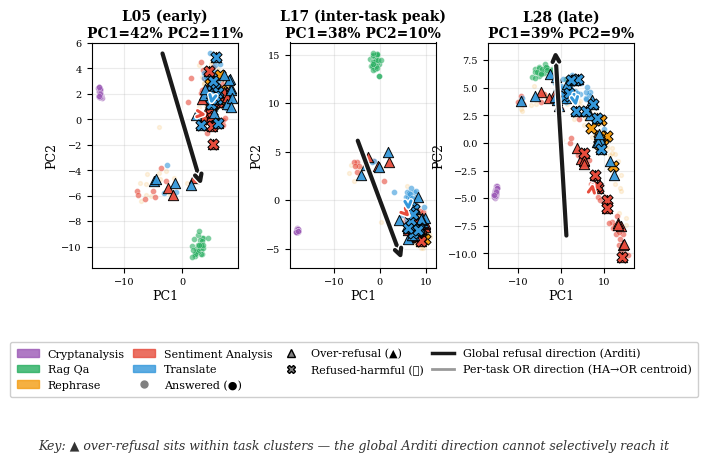

✓ Fig0 saved: fig13a_00_2d_key.pdf/png

=== FIGURE DATA (Fig 0: 2D PCA representation) ===
  L05 (early): PC1=42.0% PC2=11.5%
    sentiment_analysis: OR-HA gap=1.788 | OR-RH gap=1.408
    translate: OR-HA gap=1.168 | OR-RH gap=0.827
  L17 (inter-task peak): PC1=38.3% PC2=10.5%
    sentiment_analysis: OR-HA gap=1.486 | OR-RH gap=1.334
    translate: OR-HA gap=1.317 | OR-RH gap=2.185
  L28 (late): PC1=39.0% PC2=8.8%
    sentiment_analysis: OR-HA gap=0.705 | OR-RH gap=3.674
    translate: OR-HA gap=1.766 | OR-RH gap=4.781


In [6]:
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

VIZ_LAYERS_KEY = [
    ('layer_5_input_norm',  'L05 (early)'),
    (BEST_LAYER,            f'L{int(BEST_LAYER.split("_")[1]):02d} (inter-task peak)'),
    ('layer_28_input_norm', 'L28 (late)'),
]

fig, axes = plt.subplots(1, 3, figsize=(7.0, 4.5))
plt.subplots_adjust(wspace=0.35, bottom=0.42, top=0.92)

def draw_fap(ax, xy0, xy1, color, lw, zorder=10, ms=12):
    ax.add_patch(FancyArrowPatch(
        xy0, xy1, arrowstyle='->', mutation_scale=ms,
        color=color, linewidth=lw, zorder=zorder, clip_on=False,
        path_effects=[pe.withStroke(linewidth=lw+2.0, foreground='white')]
    ))

for ax, (lname, layer_label) in zip(axes, VIZ_LAYERS_KEY):
    emb   = embeddings_np[lname]
    pca2  = pca2_per_layer[lname]
    emb2d = emb2d_per_layer[lname]

    # ── 1. Scatter (task colour, behavior shape) ───────────────
    for task in ALL_TASKS:
        tmask = intended_task_labels == task
        col   = TASK_COLORS[task]
        ha_m  = tmask & HARMLESS_ANSWERED_MASK
        or_m  = tmask & OVER_REFUSAL_MASK
        rh_m  = tmask & REFUSED_HARMFUL_MASK
        bg    = tmask & ~ha_m & ~or_m & ~rh_m
        if bg.any():
            ax.scatter(emb2d[bg,  0], emb2d[bg,  1], c=col, s=8,  alpha=0.12, marker='o', zorder=1)
        if ha_m.any():
            ax.scatter(emb2d[ha_m,0], emb2d[ha_m,1], c=col, s=18, alpha=0.60, marker='o',
                       edgecolors='white', linewidths=0.3, zorder=2)
        if or_m.any():
            ax.scatter(emb2d[or_m,0], emb2d[or_m,1], c=col, s=55, alpha=0.95, marker='^',
                       edgecolors='black', linewidths=0.7, zorder=3)
        if rh_m.any():
            ax.scatter(emb2d[rh_m,0], emb2d[rh_m,1], c=col, s=65, alpha=1.00, marker='X',
                       edgecolors='black', linewidths=0.7, zorder=3)

    # ── 2. Direction arrows ────────────────────────────────────
    x_rng = emb2d[:,0].max() - emb2d[:,0].min()
    y_rng = emb2d[:,1].max() - emb2d[:,1].min()
    sc    = 0.28 * max(x_rng, y_rng)
    cx, cy = emb2d[:,0].mean(), emb2d[:,1].mean()

    # Arditi global direction — BEHIND (zorder=8)
    ard_d = arditi_dirs.get(lname, None)
    if ard_d is None:
        rh_mu = emb[REFUSED_HARMFUL_MASK].mean(0)
        ha_mu = emb[DIRECTION_HA_MASK].mean(0)
        ard_d = (rh_mu - ha_mu)
    ard_d = ard_d / (np.linalg.norm(ard_d) + 1e-8)
    d2a = pca2.components_ @ ard_d
    d2a = d2a / (np.linalg.norm(d2a) + 1e-8)
    draw_fap(ax, (cx - d2a[0]*sc, cy - d2a[1]*sc),
                 (cx + d2a[0]*sc, cy + d2a[1]*sc),
                 color='#1a1a1a', lw=3.0, zorder=8)

    # Per-task OR direction: HA centroid → OR centroid — ON TOP (zorder=11)
    for task in TASKS_WITH_OR:
        or_m_t = (intended_task_labels == task) & OVER_REFUSAL_MASK
        ha_m_t = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
        if or_m_t.sum() < 2 or ha_m_t.sum() < 2:
            continue
        ha_c = emb2d[ha_m_t].mean(0)
        or_c = emb2d[or_m_t].mean(0)
        draw_fap(ax, tuple(ha_c), tuple(or_c),
                 color=TASK_COLORS[task], lw=2.2, zorder=11, ms=11)

    var = pca2.explained_variance_ratio_
    ax.set_title(f'{layer_label}\nPC1={var[0]:.0%} PC2={var[1]:.0%}',
                 fontsize=10, fontweight='bold', pad=4)
    ax.set_xlabel('PC1', fontsize=9, labelpad=2)
    ax.set_ylabel('PC2', fontsize=9, labelpad=2)
    ax.tick_params(labelsize=7)

# ── Legend ─────────────────────────────────────────────────────
leg = [Patch(color=TASK_COLORS[t], alpha=0.8, label=t.replace('_',' ').title()) for t in ALL_TASKS]
leg += [
    Line2D([0],[0], marker='o', color='grey', lw=0, ms=5, label='Answered (●)'),
    Line2D([0],[0], marker='^', color='grey', lw=0, ms=6, label='Over-refusal (▲)', markeredgecolor='k'),
    Line2D([0],[0], marker='X', color='grey', lw=0, ms=6, label='Refused-harmful (✕)', markeredgecolor='k'),
    Line2D([0],[0], color='#1a1a1a', lw=2.5, label='Global refusal direction (Arditi)'),
    Line2D([0],[0], color='grey', lw=2.0, alpha=0.8, label='Per-task OR direction (HA→OR centroid)'),
]
fig.legend(handles=leg, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, 0.12), framealpha=0.95, borderpad=0.6, columnspacing=0.7)
fig.text(0.5, 0.01,
         'Key: ▲ over-refusal sits within task clusters — the global Arditi direction cannot selectively reach it',
         ha='center', va='bottom', fontsize=9, style='italic', color='#333')

plt.savefig('fig13a_00_2d_key.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig13a_00_2d_key.png', bbox_inches='tight', dpi=300)
plt.show()
print('✓ Fig0 saved: fig13a_00_2d_key.pdf/png')

print()
print('=== FIGURE DATA (Fig 0: 2D PCA representation) ===')
for lname, lbl in VIZ_LAYERS_KEY:
    var = pca2_per_layer[lname].explained_variance_ratio_
    print(f'  {lbl}: PC1={var[0]:.1%} PC2={var[1]:.1%}')
    for task in TASKS_WITH_OR:
        or_m_t = (intended_task_labels == task) & OVER_REFUSAL_MASK
        ha_m_t = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
        if or_m_t.sum() < 2 or ha_m_t.sum() < 2:
            continue
        e2d = emb2d_per_layer[lname]
        ha_c, or_c = e2d[ha_m_t].mean(0), e2d[or_m_t].mean(0)
        rh_c = e2d[REFUSED_HARMFUL_MASK].mean(0)
        print(f'    {task}: OR-HA gap={np.linalg.norm(or_c-ha_c):.3f} | OR-RH gap={np.linalg.norm(or_c-rh_c):.3f}')
print('='*50)


---
## Section 1 — The 32-Layer Behavioral Galaxy Map  [NB7-aligned]

**Framing change from original NB13a:** In NB7 we established that task constellations dominate the embedding geometry, and behavioral separation (target vs. over-refusal) is a *within-cluster* signal. This section now puts that to the test across all 32 layers.

**Figure 1 — Behavioral Galaxy Grid:** Primary color = behavioral class (green = target/answered; red = over-refusal/benign refused; orange = refused-harmful; grey = other). Task identity shown as faint background clouds.

**Figure 1b — Dual Galaxy Map:** At the peak-constellation layer, the SAME UMAP is shown twice: LEFT = task identity, RIGHT = behavioral class. This directly answers: do the red X marks (over-refusal) form a global "refusal cluster" independent of task, or do they sit *inside* task-coloured clouds?

**Figure 1c — Per-Task Behavioral Separation:** Centroid distance (target vs. over-refusal) and within-task silhouette per task, computed in high-dim space across all 32 layers — with the mean inter-task distance plotted as a scale reference. This answers whether the behavioral gap is large or negligible relative to the task gap.

**Silhouette score in panel titles:** Still the inter-task silhouette — tracks task constellation strength, not behavioral separation.

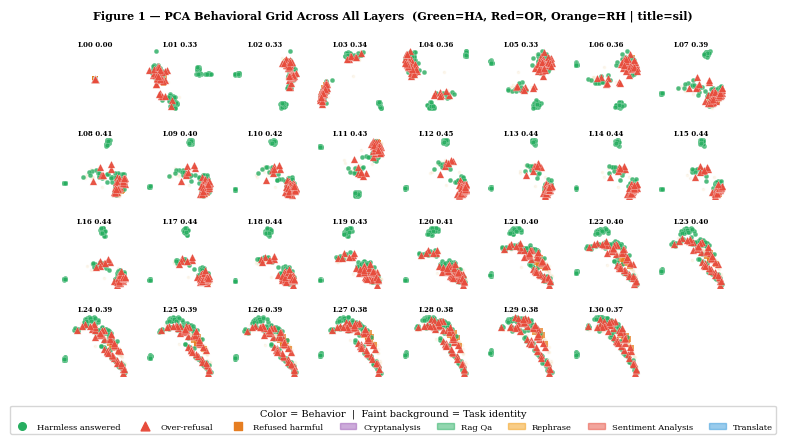

Saved: fig_nb13a_behavior_grid.pdf
KEY: Red ^ (over-refusal) within task-colour clouds → OR is within-cluster, not global


In [7]:
# ── FIGURE 1 — 32-Layer PCA Behavioral Grid ───────────────────────────────────
# Primary color = behavioral class | Background = task identity (faint)
# Uses emb2d_per_layer (PCA per layer, precomputed above)

BEH_COLORS_F1 = {
    'harmless_answered': '#27AE60',   # green
    'over_refusal':      '#E74C3C',   # red
    'refused_harmful':   '#E67E22',   # orange
    'other':             '#BDC3C7',   # grey
}
BEH_MARKERS_F1 = {
    'harmless_answered': 'o',
    'over_refusal':      '^',
    'refused_harmful':   's',
    'other':             '.',
}
BEH_ALPHA_F1 = {'harmless_answered': 0.80, 'over_refusal': 0.95, 'refused_harmful': 0.75, 'other': 0.10}
BEH_SIZE_F1  = {'harmless_answered': 12,   'over_refusal': 28,   'refused_harmful': 18,   'other': 4}
BEH_PLOT_ORDER_F1 = ['other', 'refused_harmful', 'harmless_answered', 'over_refusal']

N_COLS, N_ROWS = 8, 4
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(7.0, 4.0))
axes_flat = axes.flatten()

for i, lname in enumerate(LAYER_NAMES):
    ax     = axes_flat[i]
    emb_2d = emb2d_per_layer[lname]   # (N, 2) — PCA
    sil    = task_sil_per_layer[lname]

    # Background: faint task-coloured clouds
    for task in ALL_TASKS:
        tmask = intended_task_labels == task
        ax.scatter(emb_2d[tmask, 0], emb_2d[tmask, 1],
                   c=TASK_COLORS[task], s=3, alpha=0.05, rasterized=True, zorder=1)

    # Foreground: behavior-coloured points
    for beh in BEH_PLOT_ORDER_F1:
        bmask = beh_labels == beh
        if bmask.sum() == 0:
            continue
        ax.scatter(emb_2d[bmask, 0], emb_2d[bmask, 1],
                   c=BEH_COLORS_F1[beh], marker=BEH_MARKERS_F1[beh],
                   s=BEH_SIZE_F1[beh], alpha=BEH_ALPHA_F1[beh],
                   linewidths=0.15,
                   edgecolors='white' if beh in ('harmless_answered', 'over_refusal') else 'none',
                   rasterized=True, zorder=3)

    sil_str = f'{sil:.2f}' if not np.isnan(sil) else 'N/A'
    ax.set_title(f'L{i:02d} {sil_str}', fontsize=5, fontweight='bold', pad=1)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Hide unused panels
for j in range(len(LAYER_NAMES), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Legend
beh_handles = [
    plt.scatter([], [], c=BEH_COLORS_F1['harmless_answered'], marker='o', s=30,
                label='Harmless answered'),
    plt.scatter([], [], c=BEH_COLORS_F1['over_refusal'],      marker='^', s=40,
                label='Over-refusal'),
    plt.scatter([], [], c=BEH_COLORS_F1['refused_harmful'],   marker='s', s=30,
                label='Refused harmful'),
]
task_handles = [mpatches.Patch(color=TASK_COLORS[t], alpha=0.5,
                               label=t.replace('_', ' ').title()) for t in ALL_TASKS]
fig.legend(handles=beh_handles + task_handles,
           loc='lower center', ncol=8, fontsize=6,
           frameon=True, bbox_to_anchor=(0.5, -0.04),
           title='Color = Behavior  |  Faint background = Task identity',
           title_fontsize=7)
fig.text(0.5, 1.01,
         'Figure 1 — PCA Behavioral Grid Across All Layers  '
         '(Green=HA, Red=OR, Orange=RH | title=sil)',
         ha='center', fontsize=8, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('fig_nb13a_behavior_grid.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_nb13a_behavior_grid.pdf')
print('KEY: Red ^ (over-refusal) within task-colour clouds → OR is within-cluster, not global')


In [8]:
# Section 1 Findings — Printed Summary
sil_vals  = [task_sil_per_layer[l] for l in LAYER_NAMES]
early_sil = np.nanmean(sil_vals[:8])
mid_sil   = np.nanmean(sil_vals[8:20])
late_sil  = np.nanmean(sil_vals[20:])
peak_sil_idx = int(np.nanargmax(sil_vals))
min_sil_idx  = int(np.nanargmin(sil_vals))

print('=' * 68)
print('SECTION 1 FINDINGS — CONSTELLATION FORMATION (INTER-TASK SILHOUETTE)')
print('=' * 68)
print(f'  Silhouette score measures how well 5 task clusters are separated.')
print(f'  Range: -1 (wrong cluster) to +1 (tight, well-separated clusters).')
print()
print(f'  Phase averages:')
print(f'    Early layers (L00-L07) mean silhouette : {early_sil:+.3f}')
print(f'    Mid   layers (L08-L19) mean silhouette : {mid_sil:+.3f}')
print(f'    Late  layers (L20-L31) mean silhouette : {late_sil:+.3f}')
print()
print(f'  Per-layer extremes:')
print(f'    Peak separation : L{peak_sil_idx:02d} = {sil_vals[peak_sil_idx]:.3f}')
print(f'    Least separated : L{min_sil_idx:02d}  = {sil_vals[min_sil_idx]:.3f}')
print()
print(f'  Full layer-by-layer silhouette scores:')
for i in range(0, N_LAYERS, 4):
    row = '  '.join(f'L{i+j:02d}:{sil_vals[i+j]:+.3f}' for j in range(4) if i+j < N_LAYERS)
    print(f'    {row}')
print()
if mid_sil > early_sil:
    print(f'  INTERPRETATION: Mid-layer silhouette ({mid_sil:.3f}) exceeds early-layer ({early_sil:.3f}),')
    print(f'  confirming that task constellations form during mid-layer processing.')
    delta = mid_sil - early_sil
    print(f'  The {delta:.3f} gain quantifies constellation formation strength.')
else:
    print(f'  NOTE: Silhouette pattern is non-standard — inspect Figure 1 for visual structure.')
print('=' * 68)

SECTION 1 FINDINGS — CONSTELLATION FORMATION (INTER-TASK SILHOUETTE)
  Silhouette score measures how well 5 task clusters are separated.
  Range: -1 (wrong cluster) to +1 (tight, well-separated clusters).

  Phase averages:
    Early layers (L00-L07) mean silhouette : +0.306
    Mid   layers (L08-L19) mean silhouette : +0.431
    Late  layers (L20-L31) mean silhouette : +0.391

  Per-layer extremes:
    Peak separation : L12 = 0.454
    Least separated : L00  = 0.000

  Full layer-by-layer silhouette scores:
    L00:+0.000  L01:+0.326  L02:+0.328  L03:+0.344
    L04:+0.361  L05:+0.332  L06:+0.365  L07:+0.392
    L08:+0.407  L09:+0.400  L10:+0.420  L11:+0.434
    L12:+0.454  L13:+0.442  L14:+0.436  L15:+0.438
    L16:+0.439  L17:+0.438  L18:+0.437  L19:+0.429
    L20:+0.412  L21:+0.402  L22:+0.398  L23:+0.398
    L24:+0.393  L25:+0.389  L26:+0.391  L27:+0.384
    L28:+0.382  L29:+0.379  L30:+0.372

  INTERPRETATION: Mid-layer silhouette (0.431) exceeds early-layer (0.306),
  confirming 

---
## Figure 1b — Dual PCA Map at Peak Constellation Layer

**The definitive visual answer to: "where do over-refusal cases sit?"**

At the peak-constellation layer (automatically detected by separation ratio), the same PCA projection is shown twice: LEFT colored by task identity, RIGHT colored by behavioral class. If red ^ marks (over-refusal) lie within task-coloured zones → over-refusal is a within-cluster, task-conditioned phenomenon — not a global signal that a single direction can capture.


Peak constellation layer: L01  (sep ratio=2.380, inter-task sil=0.326)


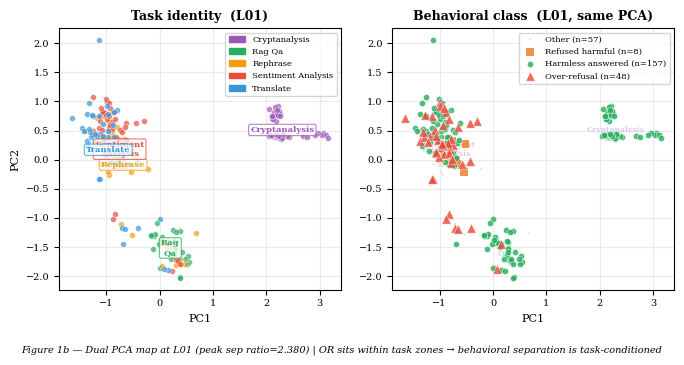


=== FIGURE DATA: DUAL GALAXY MAP ===
Peak layer: L01  sep_ratio=2.380  inter-task sil=0.326
PCA variance: PC1=56.7%, PC2=23.1%

OR position relative to task centroids at L01 (PCA space):
  sentiment_analysis    : OR=(-0.78,0.25)  HA=(-0.74,0.14)  task_cent=(-0.75,0.18)  OR-HA gap=0.119
  translate             : OR=(-0.95,0.02)  HA=(-0.98,0.30)  task_cent=(-0.96,0.17)  OR-HA gap=0.280

Saved: fig_nb13a_dual_galaxy.pdf


In [9]:
# ── FIGURE 1b — Dual PCA Map at Peak Constellation Layer ─────────────────────
# Same PCA shown twice: LEFT = task identity, RIGHT = behavioral class
# Uses emb2d_per_layer at the peak separation layer

_sep_vals        = [separation_ratio[l] for l in LAYER_NAMES]
peak_sep_idx_gal = int(np.argmax(_sep_vals))
gal_lname        = LAYER_NAMES[peak_sep_idx_gal]
gal_pca_2d       = emb2d_per_layer[gal_lname]   # (N, 2) — PCA at peak layer
gal_lno          = int(gal_lname.split('_')[1])

print(f'Peak constellation layer: L{gal_lno:02d}  '
      f'(sep ratio={_sep_vals[peak_sep_idx_gal]:.3f}, '
      f'inter-task sil={task_sil_per_layer[gal_lname]:.3f})')

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))

# ── LEFT: Task identity ────────────────────────────────────────────────────────
ax = axes[0]
for task in ALL_TASKS:
    mask  = intended_task_labels == task
    ax.scatter(gal_pca_2d[mask, 0], gal_pca_2d[mask, 1],
               c=TASK_COLORS[task], s=18, alpha=0.70,
               edgecolors='white', linewidths=0.4, rasterized=True, zorder=3)
    cx, cy = gal_pca_2d[mask, 0].mean(), gal_pca_2d[mask, 1].mean()
    ax.text(cx, cy, task.replace('_', '\n').title(),
            fontsize=6, fontweight='bold', color=TASK_COLORS[task],
            ha='center', va='center', zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.75, edgecolor=TASK_COLORS[task], linewidth=0.8))

ax.legend(handles=[mpatches.Patch(color=TASK_COLORS[t], label=t.replace('_', ' ').title())
                   for t in ALL_TASKS],
          loc='best', fontsize=6, frameon=True)
ax.set_title(f'Task identity  (L{gal_lno:02d})', fontsize=9, fontweight='bold')
ax.set_xlabel('PC1', fontsize=8); ax.set_ylabel('PC2', fontsize=8)
ax.tick_params(labelsize=7)

# ── RIGHT: Behavioral class — same PCA ────────────────────────────────────────
ax = axes[1]
for beh, color, size, zord, label_str in [
    ('other',              '#BDC3C7', 5,  1, 'Other'),
    ('refused_harmful',    '#E67E22', 30, 2, 'Refused harmful'),
    ('harmless_answered',  '#27AE60', 20, 3, 'Harmless answered'),
    ('over_refusal',       '#E74C3C', 45, 4, 'Over-refusal'),
]:
    bmask = beh_labels == beh
    if bmask.sum() == 0:
        continue
    ax.scatter(gal_pca_2d[bmask, 0], gal_pca_2d[bmask, 1],
               c=color,
               marker={'other': '.', 'refused_harmful': 's',
                       'harmless_answered': 'o', 'over_refusal': '^'}[beh],
               s=size, alpha=0.82,
               edgecolors='white' if beh in ('harmless_answered', 'over_refusal') else 'none',
               linewidths=0.4, label=f'{label_str} (n={bmask.sum()})',
               rasterized=True, zorder=zord)

# Faint task region labels for orientation
for task in ALL_TASKS:
    tmask  = intended_task_labels == task
    cx, cy = gal_pca_2d[tmask, 0].mean(), gal_pca_2d[tmask, 1].mean()
    ax.text(cx, cy, task.replace('_', '\n').title(),
            fontsize=5.5, ha='center', va='center',
            color=TASK_COLORS[task], fontweight='bold', alpha=0.30, zorder=1)

ax.legend(fontsize=6, frameon=True, loc='best')
ax.set_title(f'Behavioral class  (L{gal_lno:02d}, same PCA)', fontsize=9, fontweight='bold')
ax.set_xlabel('PC1', fontsize=8)
ax.tick_params(labelsize=7)

fig.text(0.5, -0.03,
         f'Figure 1b — Dual PCA map at L{gal_lno:02d} (peak sep ratio={_sep_vals[peak_sep_idx_gal]:.3f}) | '
         'OR sits within task zones → behavioral separation is task-conditioned',
         ha='center', fontsize=7, style='italic')
plt.tight_layout()
plt.savefig('fig_nb13a_dual_galaxy.pdf', dpi=300, bbox_inches='tight')
plt.show()

# FIGURE DATA
print(f'\n=== FIGURE DATA: DUAL GALAXY MAP ===')
print(f'Peak layer: L{gal_lno:02d}  sep_ratio={_sep_vals[peak_sep_idx_gal]:.3f}  '
      f'inter-task sil={task_sil_per_layer[gal_lname]:.3f}')
pca_var = pca2_per_layer[gal_lname].explained_variance_ratio_
print(f'PCA variance: PC1={pca_var[0]:.1%}, PC2={pca_var[1]:.1%}')
print(f'\nOR position relative to task centroids at L{gal_lno:02d} (PCA space):')
for task in TASKS_WITH_OR:
    or_m  = (intended_task_labels == task) & OVER_REFUSAL_MASK
    ha_m  = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
    all_m = intended_task_labels == task
    if or_m.sum() < 2: continue
    or_c  = gal_pca_2d[or_m].mean(0)
    ha_c  = gal_pca_2d[ha_m].mean(0)
    tc    = gal_pca_2d[all_m].mean(0)
    print(f'  {task:<22}: OR=({or_c[0]:.2f},{or_c[1]:.2f})  '
          f'HA=({ha_c[0]:.2f},{ha_c[1]:.2f})  '
          f'task_cent=({tc[0]:.2f},{tc[1]:.2f})  '
          f'OR-HA gap={np.linalg.norm(or_c-ha_c):.3f}')
print('\nSaved: fig_nb13a_dual_galaxy.pdf')


---
## Figure 1c — Per-Task Target vs. Over-Refusal Separation  [NB7 Cell 32 analogue]

**The scale comparison that matters:** Is the within-task behavioral gap (target ↔ over-refusal centroid distance) large or small relative to the inter-task gap?

- **Panel 1 — Centroid distance:** Solid lines = within-task target↔over-refusal L2 distance per task, across all 32 layers. Dashed black = mean inter-task centroid distance (the scale reference from Section 2). If the solid lines are far below the dashed line, over-refusal cases are geometrically much closer to their task's target samples than to any other task.

- **Panel 2 — Within-task silhouette:** Same as Section 3's crystallization heatmap but displayed as line plots for direct cross-task comparison. Values near 0 = refused and answered samples overlap in that task's cluster. Values above 0.3 = meaningful separation.

**Why this grounds the NB7 narrative:** If solid << dashed throughout, the behavioral signal is secondary to task identity — Arditi's single direction must sacrifice task-specific structure.

Tasks with ≥2 target and ≥2 over-refusal samples: ['sentiment_analysis', 'translate']
  sentiment_analysis    : target n=32  OR n=20  max gap=9.3 @ L14  (inter-task mean @ L14 = 22.0)
  translate             : target n=23  OR n=28  max gap=8.4 @ L20  (inter-task mean @ L20 = 18.8)


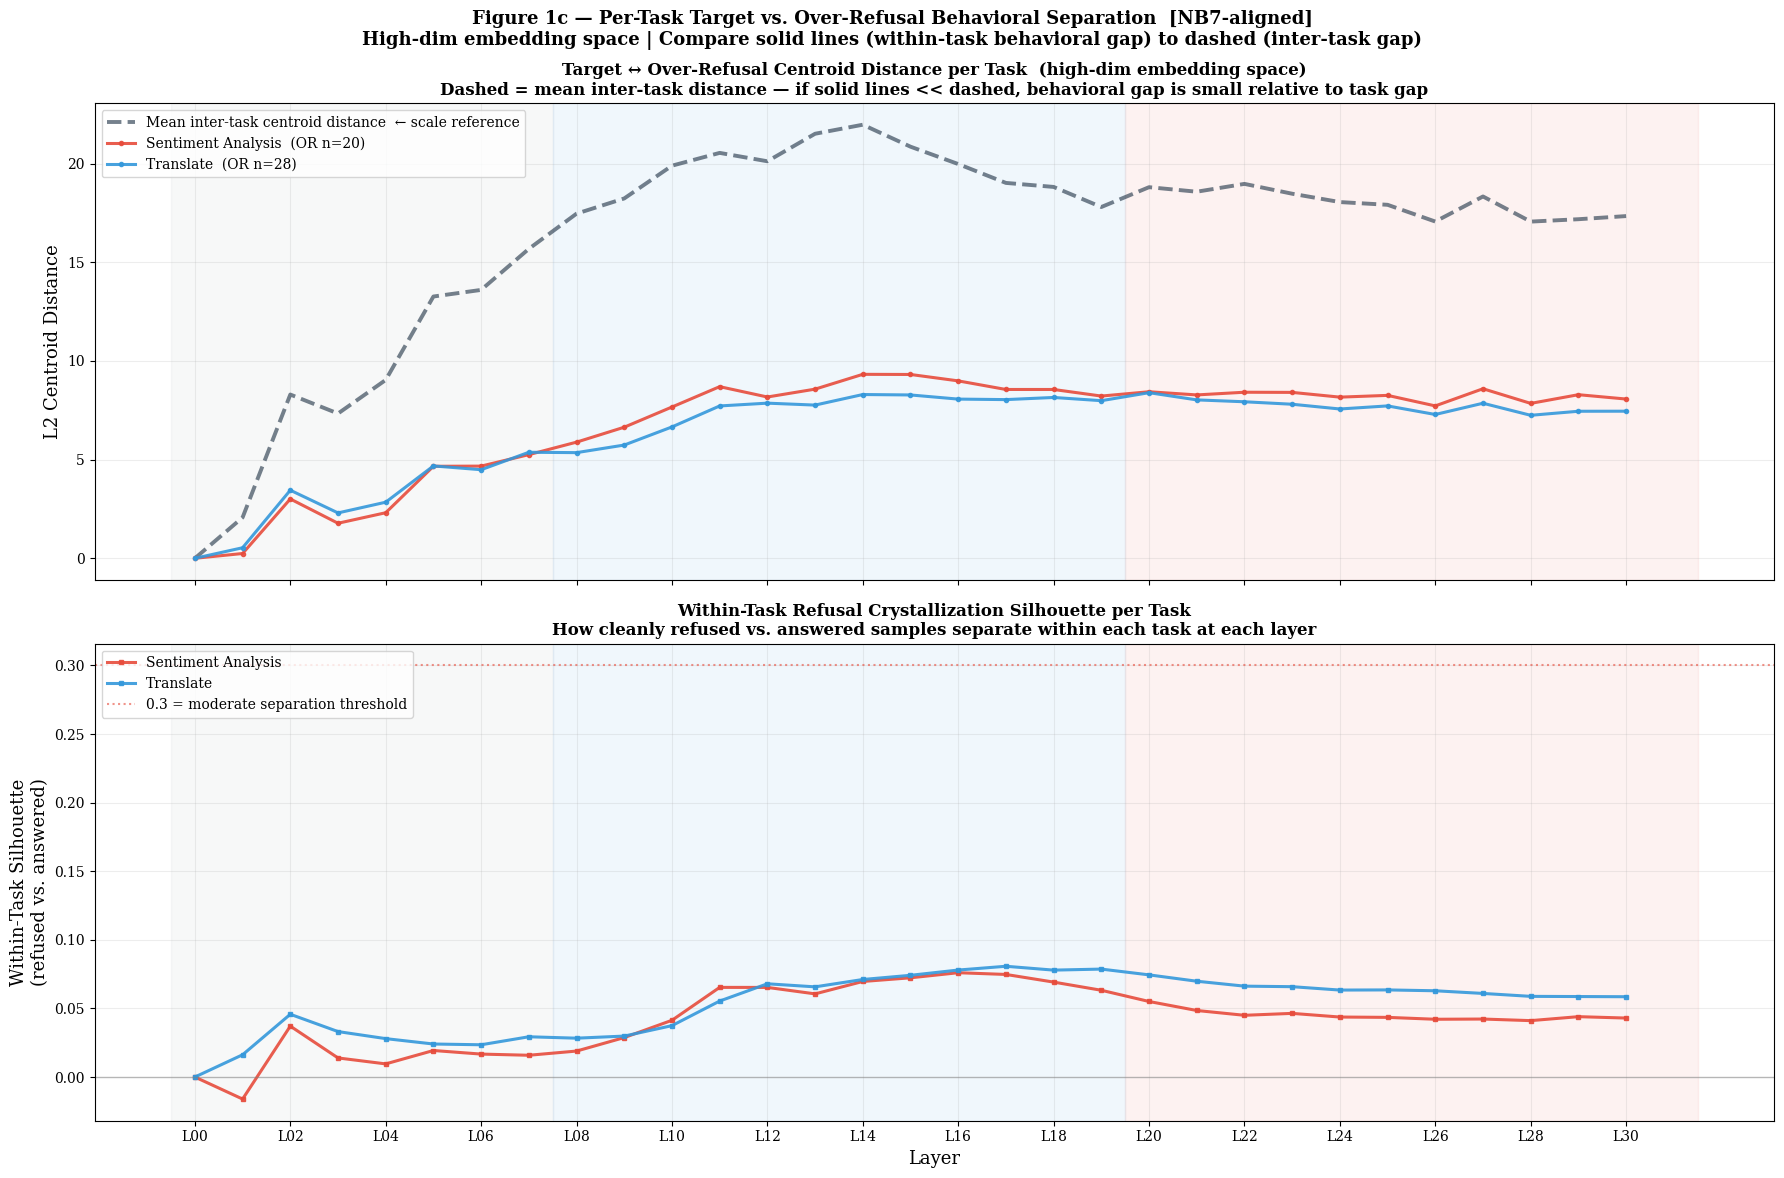

Saved: fig1c_per_task_behavioral_separation.pdf

INTERPRETATION GUIDE:
  solid << dashed  →  over-refusal cases are geometrically closer to their own
                       task's target samples than to any other task's samples.
                       Refusal is within-cluster; Arditi loses task-specific info.
  solid ≈ dashed   →  over-refusal cases drift as far from target as they drift
                       from other tasks. A global refusal direction is plausible.


In [10]:
# Figure 1c — Per-Task Target vs. Over-Refusal Separation  [NB7 Cell 32 analogue]
# All metrics computed in HIGH-DIMENSIONAL embedding space — no UMAP, no projection artifacts.
# Panel 1: within-task centroid distance vs. mean inter-task distance (scale reference)
# Panel 2: within-task silhouette (refused vs. answered) per task

TASKS_WITH_OR_13a = [
    t for t in ALL_TASKS
    if (TARGET_MASK       & (intended_task_labels == t)).sum() >= 2 and
       (OVER_REFUSAL_MASK & (intended_task_labels == t)).sum() >= 2
]
print(f'Tasks with ≥2 target and ≥2 over-refusal samples: {TASKS_WITH_OR_13a}')

layer_nums     = list(range(N_LAYERS))
inter_vals_ref = [inter_centroid_dist[l] for l in LAYER_NAMES]   # already precomputed

# ── Compute target↔over-refusal centroid distance per task per layer ──────────
cdist_data = {}
cryst_data = {}

for task in TASKS_WITH_OR_13a:
    tmask    = intended_task_labels == task
    tgt_mask = TARGET_MASK & tmask
    or_mask  = OVER_REFUSAL_MASK & tmask
    n_tgt, n_or = tgt_mask.sum(), or_mask.sum()

    dists  = []
    crysts = []
    for lname in LAYER_NAMES:
        emb   = embeddings_np[lname]
        c_tgt = emb[tgt_mask].mean(axis=0)
        c_or  = emb[or_mask].mean(axis=0)
        dists.append(float(np.linalg.norm(c_tgt - c_or)))
        crysts.append(cryst_sil.get((task, lname), np.nan))

    cdist_data[task] = dists
    cryst_data[task] = crysts
    peak_l = int(np.argmax(dists))
    print(f'  {task:<22}: target n={n_tgt}  OR n={n_or}  '
          f'max gap={max(dists):.1f} @ L{peak_l:02d}  '
          f'(inter-task mean @ L{peak_l:02d} = {inter_vals_ref[peak_l]:.1f})')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)
TASK_LINE_COLORS = [TASK_COLORS[t] for t in TASKS_WITH_OR_13a]

# Panel 1: Centroid distance
ax = axes[0]
ax.plot(layer_nums, inter_vals_ref, color='#2C3E50', lw=2.8, ls='--', alpha=0.65, zorder=2,
        label='Mean inter-task centroid distance  ← scale reference')
for task, color in zip(TASKS_WITH_OR_13a, TASK_LINE_COLORS):
    n_or = (OVER_REFUSAL_MASK & (intended_task_labels == task)).sum()
    ax.plot(layer_nums, cdist_data[task], color=color, lw=2.2, marker='o', ms=3,
            label=f'{task.replace("_"," ").title()}  (OR n={n_or})', alpha=0.90, zorder=3)

ax.axvspan(-0.5,  7.5, alpha=0.07, color='#95A5A6')
ax.axvspan( 7.5, 19.5, alpha=0.07, color='#3498DB')
ax.axvspan(19.5, 31.5, alpha=0.07, color='#E74C3C')
ax.set_ylabel('L2 Centroid Distance', fontsize=13)
ax.set_title(
    'Target ↔ Over-Refusal Centroid Distance per Task  (high-dim embedding space)\n'
    'Dashed = mean inter-task distance — if solid lines << dashed, '
    'behavioral gap is small relative to task gap',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10, frameon=True, loc='upper left')
ax.grid(True, alpha=0.22)

# Panel 2: Within-task silhouette
ax = axes[1]
for task, color in zip(TASKS_WITH_OR_13a, TASK_LINE_COLORS):
    ax.plot(layer_nums, cryst_data[task], color=color, lw=2.2, marker='s', ms=3,
            label=task.replace('_', ' ').title(), alpha=0.90)
ax.axhline(0.0, color='grey',    ls='-',  lw=1.0, alpha=0.5)
ax.axhline(0.3, color='#E74C3C', ls=':',  lw=1.5, alpha=0.6,
           label='0.3 = moderate separation threshold')

ax.axvspan(-0.5,  7.5, alpha=0.07, color='#95A5A6')
ax.axvspan( 7.5, 19.5, alpha=0.07, color='#3498DB')
ax.axvspan(19.5, 31.5, alpha=0.07, color='#E74C3C')
ax.set_ylabel('Within-Task Silhouette\n(refused vs. answered)', fontsize=13)
ax.set_xlabel('Layer', fontsize=13)
ax.set_title(
    'Within-Task Refusal Crystallization Silhouette per Task\n'
    'How cleanly refused vs. answered samples separate within each task at each layer',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10, frameon=True, loc='upper left')
ax.grid(True, alpha=0.22)
ax.set_xticks(list(range(0, N_LAYERS, 2)))
ax.set_xticklabels([f'L{i:02d}' for i in range(0, N_LAYERS, 2)], fontsize=10)

fig.suptitle(
    'Figure 1c — Per-Task Target vs. Over-Refusal Behavioral Separation  [NB7-aligned]\n'
    'High-dim embedding space | Compare solid lines (within-task behavioral gap) '
    'to dashed (inter-task gap)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1c_per_task_behavioral_separation.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig1c_per_task_behavioral_separation.pdf')
print()
print('INTERPRETATION GUIDE:')
print('  solid << dashed  →  over-refusal cases are geometrically closer to their own')
print('                       task\'s target samples than to any other task\'s samples.')
print('                       Refusal is within-cluster; Arditi loses task-specific info.')
print('  solid ≈ dashed   →  over-refusal cases drift as far from target as they drift')
print('                       from other tasks. A global refusal direction is plausible.')

---
## Section 2 — Quantitative Constellation Profile (All 32 Layers)

Four complementary metrics across all layers, computed on the full embedding space:

1. **Inter-task centroid distance** — Mean pairwise L2 distance between the 5 task centroids. High = constellations are far apart in space.
2. **Intra-task spread** — Mean distance of samples from their task centroid. Low = constellations are compact and tight.
3. **Separation ratio** (inter / intra) — The headline metric. High = well-separated *and* compact constellations. This is the cleanest single indicator of constellation quality.
4. **Inter-task silhouette** — Classification-based: do samples lie closer to their own task centroid than to any other? (From Section 1, repeated here for direct comparison.)

Together these four metrics confirm and quantify what Figure 1 shows visually.

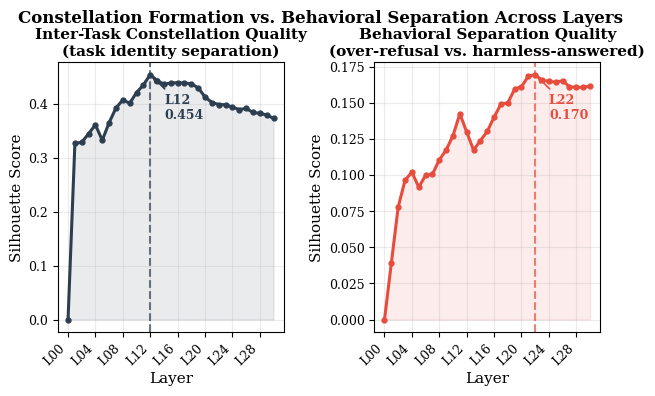

✓ Fig2 saved: fig13a_02_silhouette_curves.pdf/png

=== FIGURE DATA (Fig 2: silhouette curves) ===
  Inter-task silhouette peak: 0.4538 at L12
  Behavioral silhouette peak: 0.1698  at L22
  Ratio (inter/beh at resp. peaks): 2.7x
  Separation ratio peak: 2.380 at L01
  Layer     Inter-Sil   Beh-Sil  Sep-Ratio
  L00         0.0000    0.0000      0.000
  L05         0.3321    0.0917      1.682
  L10         0.4204    0.1274      2.019
  L12         0.4538    0.1300      2.078
  L15         0.4379    0.1304      1.981
  L20         0.4122    0.1614      1.779
  L25         0.3889    0.1645      1.690


In [11]:
# ── Figure 2 — Dual Silhouette Curves (ACL 2-column) ─────────
# Left:  Inter-task silhouette (constellation quality, peaks early ~L12)
# Right: Behavioral silhouette (OR vs HA separation, peaks later, much weaker)
# Key message: constellations form at L12 (0.357), but OR is NOT globally
# separable from HA (0.08) — OR lives INSIDE task clusters

xtick_pos    = list(range(0, N_LAYERS, 4))
xtick_labels = [f'L{i:02d}' for i in xtick_pos]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))
plt.subplots_adjust(wspace=0.40)

for ax, vals, color, title, ylabel in [
    (axes[0], sil_vals, '#2C3E50',
     'Inter-Task Constellation Quality\n(task identity separation)',
     'Silhouette Score'),
    (axes[1], beh_vals, '#E74C3C',
     'Behavioral Separation Quality\n(over-refusal vs. harmless-answered)',
     'Silhouette Score'),
]:
    pk = int(np.nanargmax(vals))
    ax.plot(range(N_LAYERS), vals, color=color, lw=2.2, marker='o', ms=3.5, zorder=5)
    ax.fill_between(range(N_LAYERS), vals, alpha=0.10, color=color)
    ax.axvline(pk, color=color, lw=1.5, ls='--', alpha=0.7)
    ax.annotate(f'L{pk:02d}\n{vals[pk]:.3f}',
                xy=(pk, vals[pk]),
                xytext=(pk + (2 if pk < N_LAYERS-4 else -5), vals[pk] * 0.82),
                fontsize=9, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_labels, fontsize=9, rotation=45, ha='right')
    ax.set_xlabel('Layer', fontsize=11, labelpad=3)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=3)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=5)
    ax.tick_params(labelsize=9)

fig.suptitle('Constellation Formation vs. Behavioral Separation Across Layers',
             fontsize=12, fontweight='bold', y=1.03)
plt.savefig('fig13a_02_silhouette_curves.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig13a_02_silhouette_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print('✓ Fig2 saved: fig13a_02_silhouette_curves.pdf/png')

print()
print('=== FIGURE DATA (Fig 2: silhouette curves) ===')
print(f'  Inter-task silhouette peak: {sil_vals[peak_inter]:.4f} at L{peak_inter:02d}')
print(f'  Behavioral silhouette peak: {beh_vals[peak_beh]:.4f}  at L{peak_beh:02d}')
print(f'  Ratio (inter/beh at resp. peaks): {sil_vals[peak_inter]/max(beh_vals[peak_beh],1e-6):.1f}x')
print(f'  Separation ratio peak: {max(sep_vals):.3f} at L{int(np.argmax(sep_vals)):02d}')
print(f'  {"Layer":<8} {"Inter-Sil":>10} {"Beh-Sil":>9} {"Sep-Ratio":>10}')
for il in [0, 5, 10, 12, 15, 20, 25, 31]:
    if il < N_LAYERS:
        print(f'  L{il:02d}     {sil_vals[il]:>10.4f} {beh_vals[il]:>9.4f} {sep_vals[il]:>10.3f}')
print('='*50)


In [12]:
# Section 2 Findings — Numeric Summary
peak_sep_idx   = int(np.argmax(sep_vals))
peak_sil_idx   = int(np.nanargmax(sil_vals))
min_intra_idx  = int(np.argmin(intra_vals))
peak_inter_idx = int(np.argmax(inter_vals))

# Safe key layers — only include indices that exist
KEY_LAYERS_PRINT = [i for i in [0, 4, 8, 12, 15, 18, 20, 24, 28, N_LAYERS - 1] if i < N_LAYERS]
KEY_LAYERS_PRINT = sorted(set(KEY_LAYERS_PRINT))   # deduplicate in case N_LAYERS-1 duplicates

print('=' * 68)
print('SECTION 2 FINDINGS — LAYER PROFILE METRICS (COMPLETE TABLE)')
print('=' * 68)
print(f'  {"Layer":<8} {"Inter-centroid":>16} {"Intra-spread":>14} {"Sep-Ratio":>11} {"Sil":>8}')
print(f'  {"-"*60}')
for i in KEY_LAYERS_PRINT:
    star = ' <-- peak separation' if i == peak_sep_idx else ''
    print(f'  L{i:02d}     {inter_vals[i]:>16.2f} {intra_vals[i]:>14.2f} '
          f'{sep_vals[i]:>11.3f} {sil_vals[i]:>8.3f}{star}')
print()
print(f'  Total layers in data            : {N_LAYERS}')
print(f'  Peak constellation sep ratio    : L{peak_sep_idx:02d} = {sep_vals[peak_sep_idx]:.3f}')
print(f'  Peak inter-task silhouette      : L{peak_sil_idx:02d} = {sil_vals[peak_sil_idx]:.3f}')
print(f'  Minimum intra-task spread       : L{min_intra_idx:02d} = {intra_vals[min_intra_idx]:.2f}')
print(f'  Maximum inter-task distance     : L{peak_inter_idx:02d} = {inter_vals[peak_inter_idx]:.2f}')
print()
if abs(peak_sep_idx - peak_sil_idx) <= 3:
    print(f'  Both separation ratio and silhouette peak near L{peak_sep_idx:02d}-L{peak_sil_idx:02d},')
    print(f'  confirming this as the primary constellation crystallization window.')
else:
    print(f'  Separation ratio peaks at L{peak_sep_idx:02d}, silhouette at L{peak_sil_idx:02d}.')
    print(f'  The {abs(peak_sep_idx - peak_sil_idx)}-layer gap suggests a staggered formation process.')
print('=' * 68)


SECTION 2 FINDINGS — LAYER PROFILE METRICS (COMPLETE TABLE)
  Layer      Inter-centroid   Intra-spread   Sep-Ratio      Sil
  ------------------------------------------------------------
  L00                 0.00           0.00       0.000    0.000
  L04                 9.04           4.57       1.979    0.361
  L08                17.47           8.53       2.048    0.407
  L12                20.12           9.68       2.078    0.454
  L15                20.86          10.53       1.981    0.438
  L18                18.82          10.06       1.870    0.437
  L20                18.81          10.57       1.779    0.412
  L24                18.05          10.48       1.722    0.393
  L28                17.06          10.31       1.655    0.382
  L30                17.34          10.61       1.635    0.372

  Total layers in data            : 31
  Peak constellation sep ratio    : L01 = 2.380
  Peak inter-task silhouette      : L12 = 0.454
  Minimum intra-task spread       : L00 = 0.00


---
## Section 3 — Within-Task Refusal Crystallization

Sections 1–2 established that tasks separate into distinct constellations. Now the question is finer: **within each task's constellation, when does the model commit to a refusal vs. non-refusal decision?**

This is measured as the **within-task silhouette score for binary refusal classification** — computed separately for each task at each layer, using only the samples belonging to that task. A high score at layer L means: at that layer, the refused vs. answered samples within Task T are clearly geometrically distinct — the model has "crystallized" its refusal decision for that task.

**Key questions:**
- Do all tasks crystallize at the same layer, or is crystallization staggered?
- Does crystallization layer correlate with the overall constellation peak?
- Which tasks are early crystallizers vs. late crystallizers?

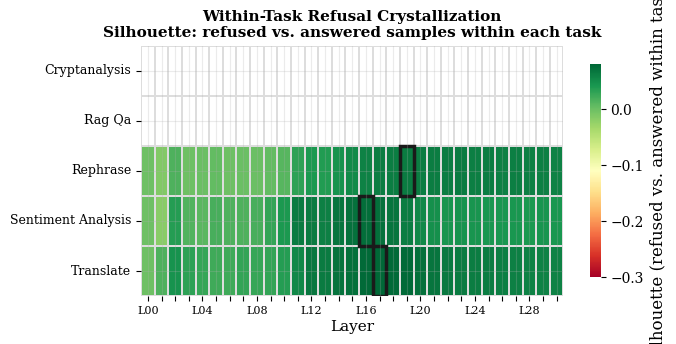

✓ Fig3 saved: fig13a_03_crystallization.pdf/png

=== FIGURE DATA (Fig 3: crystallization heatmap) ===
  cryptanalysis         : no data (< 2 refused samples)
  rag_qa                : no data (< 2 refused samples)
  rephrase              : peak +0.0659 at L19
  sentiment_analysis    : peak +0.0760 at L16
  translate             : peak +0.0807 at L17


In [13]:
# ── Figure 3 — Within-Task Refusal Crystallization Heatmap ───
cryst_matrix = np.full((len(ALL_TASKS), N_LAYERS), np.nan)
for i, task in enumerate(ALL_TASKS):
    for j, lname in enumerate(LAYER_NAMES):
        cryst_matrix[i, j] = cryst_sil.get((task, lname), np.nan)

fig, ax = plt.subplots(figsize=(7.0, 3.6))
vmax = max(np.nanmax(np.abs(cryst_matrix)), 0.01)

sns.heatmap(cryst_matrix, ax=ax,
            xticklabels=[f'L{i:02d}' if i % 4 == 0 else '' for i in range(N_LAYERS)],
            yticklabels=[t.replace('_', ' ').title() for t in ALL_TASKS],
            cmap='RdYlGn', vmin=-0.3, vmax=vmax,
            linewidths=0.3, linecolor='#ddd',
            cbar_kws={'shrink': 0.85, 'label': 'Silhouette (refused vs. answered within task)'})

for i, task in enumerate(ALL_TASKS):
    row = cryst_matrix[i, :]
    if not np.all(np.isnan(row)):
        pk_j = int(np.nanargmax(row))
        ax.add_patch(plt.Rectangle((pk_j, i), 1, 1, fill=False,
                                   edgecolor='#1a1a1a', linewidth=2.5))

ax.set_xlabel('Layer', fontsize=11, labelpad=3)
ax.set_title('Within-Task Refusal Crystallization\n'
             'Silhouette: refused vs. answered samples within each task',
             fontsize=11, fontweight='bold', pad=6)
ax.tick_params(axis='x', labelsize=8, rotation=0)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('fig13a_03_crystallization.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig13a_03_crystallization.png', bbox_inches='tight', dpi=300)
plt.show()
print('✓ Fig3 saved: fig13a_03_crystallization.pdf/png')

print()
print('=== FIGURE DATA (Fig 3: crystallization heatmap) ===')
for i, task in enumerate(ALL_TASKS):
    row = cryst_matrix[i, :]
    if not np.all(np.isnan(row)):
        pk_j = int(np.nanargmax(row))
        print(f'  {task:<22}: peak {row[pk_j]:>+.4f} at L{pk_j:02d}')
    else:
        print(f'  {task:<22}: no data (< 2 refused samples)')
print('='*50)


In [14]:
# Section 3 Findings — Crystallization Summary
print('=' * 68)
print('SECTION 3 FINDINGS — WITHIN-TASK REFUSAL CRYSTALLIZATION')
print('=' * 68)
print(f'  Crystallization layer = the layer where refused vs. answered')
print(f'  separation is strongest WITHIN each task.')
print()
print(f'  {"Task":<24} {"Peak Layer":>12} {"Peak Sil":>10} {"Interpretation"}')
print(f'  {"-"*65}')
cryst_peak_layers = []
for task in ALL_TASKS:
    row = [cryst_sil.get((task, l), np.nan) for l in LAYER_NAMES]
    if np.all(np.isnan(row)):
        print(f'  {task:<24} {"N/A":>12} {"N/A":>10}  insufficient data')
    else:
        pk_j   = int(np.nanargmax(row))
        pk_val = float(np.nanmax(row))
        cryst_peak_layers.append(pk_j)
        phase  = 'Early' if pk_j < 8 else ('Mid' if pk_j < 20 else 'Late')
        quality = 'Strong' if pk_val > 0.3 else ('Moderate' if pk_val > 0.1 else 'Weak')
        print(f'  {task:<24} {"L"+str(pk_j).zfill(2):>12} {pk_val:>10.3f}  {phase} | {quality} crystallization')
print()
if len(cryst_peak_layers) >= 2:
    spread = max(cryst_peak_layers) - min(cryst_peak_layers)
    print(f'  Crystallization layer range: L{min(cryst_peak_layers):02d} to L{max(cryst_peak_layers):02d} (spread = {spread} layers)')
    if spread >= 4:
        print(f'  FINDING: Tasks crystallize at DIFFERENT layers ({spread}-layer spread).')
        print(f'  This staggering is mechanistic evidence of task-conditioned refusal processing:')
        print(f'  different tasks commit their behavioral decision at different depths.')
    else:
        print(f'  FINDING: Tasks crystallize at similar layers (spread = {spread}),')
        print(f'  suggesting a more uniform refusal mechanism across tasks at this depth.')
print('=' * 68)

SECTION 3 FINDINGS — WITHIN-TASK REFUSAL CRYSTALLIZATION
  Crystallization layer = the layer where refused vs. answered
  separation is strongest WITHIN each task.

  Task                       Peak Layer   Peak Sil Interpretation
  -----------------------------------------------------------------
  cryptanalysis                     N/A        N/A  insufficient data
  rag_qa                            N/A        N/A  insufficient data
  rephrase                          L19      0.066  Mid | Weak crystallization
  sentiment_analysis                L16      0.076  Mid | Weak crystallization
  translate                         L17      0.081  Mid | Weak crystallization

  Crystallization layer range: L16 to L19 (spread = 3 layers)
  FINDING: Tasks crystallize at similar layers (spread = 3),
  suggesting a more uniform refusal mechanism across tasks at this depth.


---
## Section 4 — Cross-Task Centroid Distance: Does Constellation Separation Persist?

How far apart are the 5 task constellations, pairwise, at four key layers? This directly measures whether the constellation geometry grows, holds, or collapses as we move from early to late layers.

A 5×5 heatmap at each key layer: cell [i,j] = L2 distance between the centroid of Task i and Task j. All four heatmaps share the same color scale, so distances are directly comparable across layers.

**What to look for:** Do off-diagonal values grow from L05 → L12 → L20 → L30 (diverging constellations), or do they shrink (converging toward a single shared representation)?

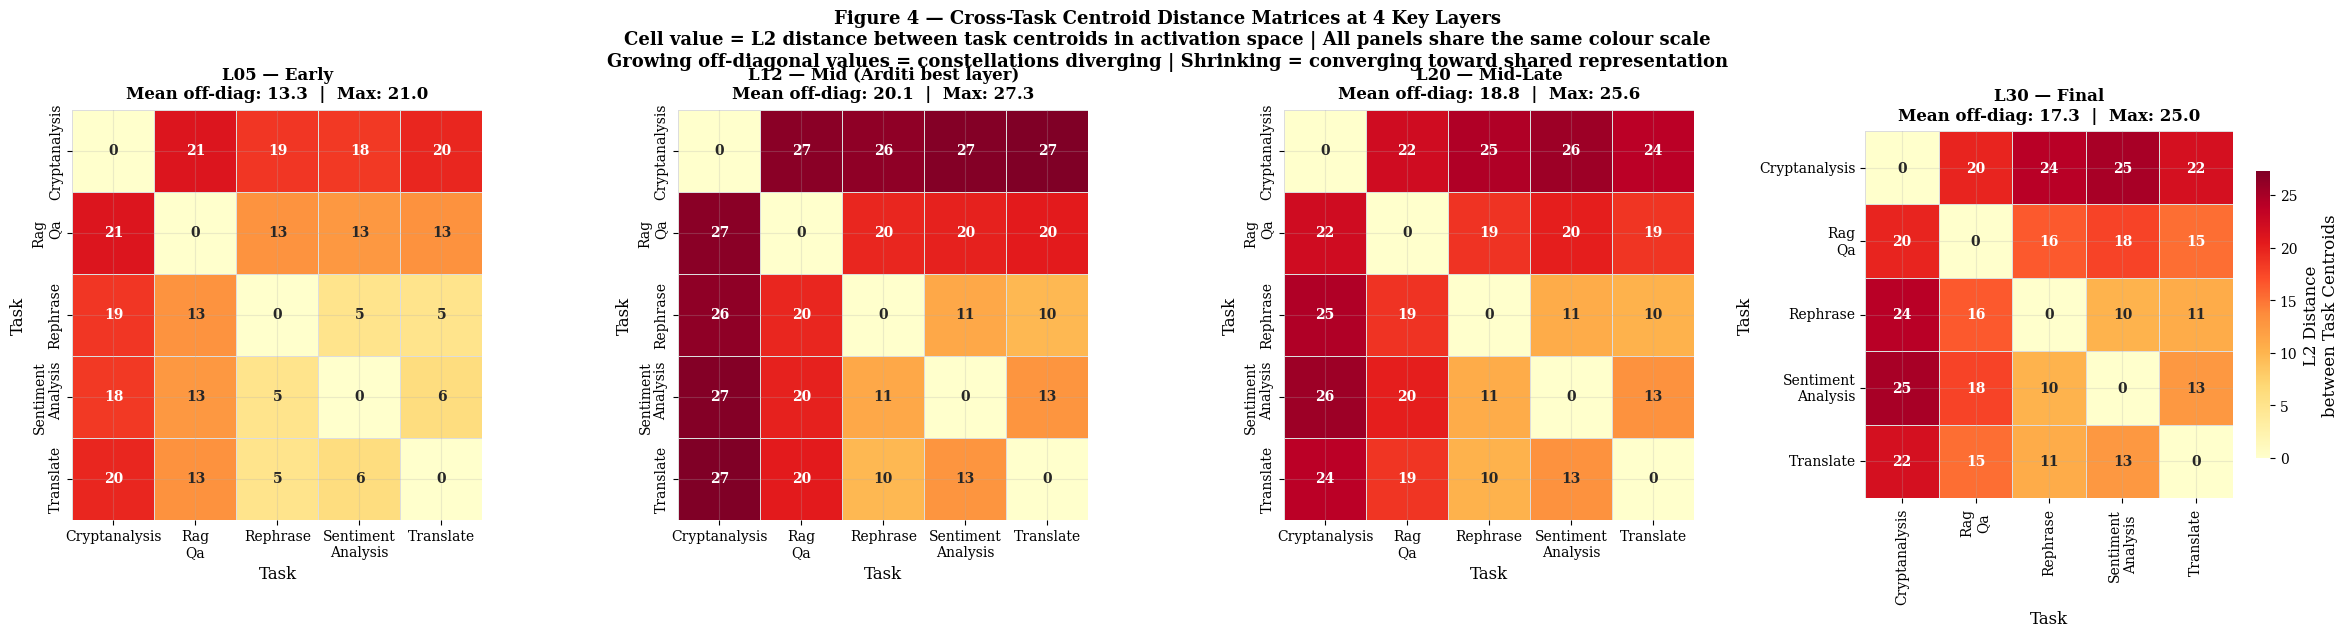

Saved: fig4_centroid_distance_heatmaps.pdf


In [15]:
# Figure 4 — Cross-Task Centroid Distance Heatmaps at 4 Key Layers
KEY_L = [
    ('layer_5_input_norm',  'L05 — Early'),
    ('layer_12_input_norm', 'L12 — Mid (Arditi best layer)'),
    ('layer_20_input_norm', 'L20 — Mid-Late'),
    ('layer_30_input_norm', 'L30 — Final'),
]
task_labels_short = [t.replace('_', '\n').title() for t in ALL_TASKS]

# Shared vmax across all 4 for fair comparison
vmax_global = max(
    centroid_matrices[k].max() for k, _ in KEY_L if k in centroid_matrices
)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (lname, title) in zip(axes, KEY_L):
    if lname not in centroid_matrices:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        continue
    mat = centroid_matrices[lname]
    off_diag_vals = mat[~np.eye(len(ALL_TASKS), dtype=bool)]
    mean_off = float(off_diag_vals.mean())
    max_off  = float(off_diag_vals.max())

    im = sns.heatmap(
        mat, ax=ax,
        xticklabels=task_labels_short,
        yticklabels=task_labels_short,
        cmap='YlOrRd', vmin=0, vmax=vmax_global,
        annot=True, fmt='.0f', annot_kws={'size': 10, 'weight': 'bold'},
        square=True, linewidths=0.4, linecolor='#ddd',
        cbar=(ax == axes[-1]),
        cbar_kws={'shrink': 0.7, 'label': 'L2 Distance\nbetween Task Centroids'},
    )
    ax.set_title(
        f'{title}\nMean off-diag: {mean_off:.1f}  |  Max: {max_off:.1f}',
        fontsize=12, fontweight='bold', pad=8,
    )
    ax.tick_params(labelsize=10, axis='both')
    ax.set_xlabel('Task', fontsize=12)
    ax.set_ylabel('Task', fontsize=12)

fig.suptitle(
    'Figure 4 — Cross-Task Centroid Distance Matrices at 4 Key Layers\n'
    'Cell value = L2 distance between task centroids in activation space | All panels share the same colour scale\n'
    'Growing off-diagonal values = constellations diverging | Shrinking = converging toward shared representation',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig4_centroid_distance_heatmaps.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig4_centroid_distance_heatmaps.pdf')

In [16]:
# Section 4 Findings — Centroid Distance Summary
print('=' * 68)
print('SECTION 4 FINDINGS — CROSS-TASK CENTROID DISTANCES')
print('=' * 68)
print(f'  {"Layer":<28} {"Mean off-diag":>15} {"Max off-diag":>14} {"Trend"}')
print(f'  {"-"*65}')

prev_mean = None
for lname, title in KEY_L:
    if lname not in centroid_matrices:
        print(f'  {title:<28} {"N/A":>15} {"N/A":>14}')
        continue
    mat      = centroid_matrices[lname]
    off_mask = ~np.eye(len(ALL_TASKS), dtype=bool)
    mean_off = float(mat[off_mask].mean())
    max_off  = float(mat[off_mask].max())
    trend    = ''
    if prev_mean is not None:
        diff  = mean_off - prev_mean
        trend = f'+{diff:.1f} (diverging)' if diff > 0 else f'{diff:.1f} (converging)'
    print(f'  {title:<28} {mean_off:>15.1f} {max_off:>14.1f}  {trend}')
    prev_mean = mean_off

print()
# Most / least separated task pair at L12
if 'layer_12_input_norm' in centroid_matrices:
    mat12 = centroid_matrices['layer_12_input_norm']
    off_idx = [(mat12[i,j], ALL_TASKS[i], ALL_TASKS[j])
               for i in range(len(ALL_TASKS)) for j in range(i+1, len(ALL_TASKS))]
    off_idx.sort(reverse=True)
    print(f'  At L12 (Arditi best layer):')
    print(f'    Most separated pair  : {off_idx[0][1]} vs {off_idx[0][2]} = {off_idx[0][0]:.1f}')
    print(f'    Least separated pair : {off_idx[-1][1]} vs {off_idx[-1][2]} = {off_idx[-1][0]:.1f}')
    ratio = off_idx[0][0] / (off_idx[-1][0] + 1e-6)
    print(f'    Spread ratio (max/min): {ratio:.1f}x — this is the within-layer task geometry Arditi ignores')
print('=' * 68)

SECTION 4 FINDINGS — CROSS-TASK CENTROID DISTANCES
  Layer                          Mean off-diag   Max off-diag Trend
  -----------------------------------------------------------------
  L05 — Early                             13.3           21.0  
  L12 — Mid (Arditi best layer)            20.1           27.3  +6.9 (diverging)
  L20 — Mid-Late                          18.8           25.6  -1.3 (converging)
  L30 — Final                             17.3           25.0  -1.5 (converging)

  At L12 (Arditi best layer):
    Most separated pair  : cryptanalysis vs translate = 27.3
    Least separated pair : rephrase vs translate = 9.7
    Spread ratio (max/min): 2.8x — this is the within-layer task geometry Arditi ignores


---
## Section 5 — Arditi Direction Validation: Is There a Universal Refusal Direction?

Arditi et al. claim a **single direction** mediates refusal across all inputs. In our data, we have 3 tasks with enough refused-harmful and harmless-answered samples to compute a task-specific refusal direction. We now ask:

**5a — Do task-specific refusal directions point the same way?** Compute cosine similarity between the task-specific directions at each layer. If all tasks share one direction: all cosine similarities → 1.0. If directions diverge: values fall below 1.0, revealing task-conditioned structure.

**5b — Does Arditi's direction capture each task's refusal direction?** Compute cosine similarity between each task's direction and Arditi's per-layer candidate direction. Near 1.0 = Arditi's direction fully represents that task. Divergence = a systematic gap.

**The key interpretive question:** Does direction convergence happen *before*, *during*, or *after* constellation formation? This determines whether Arditi's approach captures the mechanistically relevant layer.

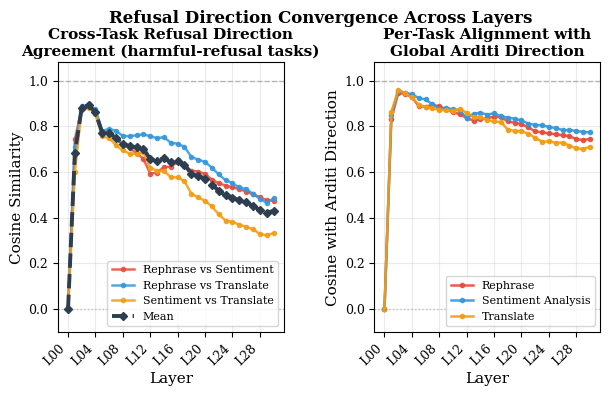

✓ Fig5 saved: fig13a_05_direction_convergence.pdf/png

=== FIGURE DATA (Fig 5: direction convergence) ===
  At best layer L17:
    rephrase vs sentiment: cos=+0.6256
    rephrase vs translate: cos=+0.7095
    sentiment vs translate: cos=+0.5598
  Mean cross-task cosine at L17: +0.6316
  Arditi alignment at L17:
    rephrase: +0.8394
    sentiment_analysis: +0.8440
    translate: +0.8176


In [17]:
# ── Figure 5 — Refusal Direction Convergence (2-panel, ACL) ──
PAIR_COLORS = ['#E74C3C', '#3498DB', '#F39C12', '#27AE60', '#9B59B6']
xtick_pos    = list(range(0, N_LAYERS, 4))
xtick_labels = [f'L{i:02d}' for i in xtick_pos]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))
plt.subplots_adjust(wspace=0.40)

# Left: cross-task direction similarity
ax = axes[0]
for (t1, t2), color in zip(dir_pairs, PAIR_COLORS):
    label = f'{t1.split("_")[0].title()} vs {t2.split("_")[0].title()}'
    ax.plot(range(N_LAYERS), pair_sims[(t1, t2)], color=color,
            lw=1.8, marker='o', ms=3, label=label, alpha=0.85)
if mean_cross_sim:
    ax.plot(range(N_LAYERS), mean_cross_sim, color='#2C3E50', lw=2.8,
            ls='--', marker='D', ms=4, label='Mean', zorder=5)
ax.axhline(1.0, color='grey', ls='--', lw=1.0, alpha=0.5)
ax.axhline(0.0, color='grey', ls=':',  lw=1.0, alpha=0.4)
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Layer', fontsize=11, labelpad=3)
ax.set_ylabel('Cosine Similarity', fontsize=11, labelpad=3)
ax.set_title('Cross-Task Refusal Direction\nAgreement (harmful-refusal tasks)',
             fontsize=11, fontweight='bold', pad=5)
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(-0.1, 1.08)
ax.tick_params(labelsize=9)

# Right: per-task Arditi alignment
ax2 = axes[1]
for t, color in zip(VALID_DIR_TASKS, PAIR_COLORS):
    ax2.plot(range(len(arditi_align[t])), arditi_align[t], color=color,
             lw=1.8, marker='o', ms=3, label=t.replace('_', ' ').title(), alpha=0.9)
ax2.axhline(1.0, color='grey', ls='--', lw=1.0, alpha=0.5)
ax2.axhline(0.0, color='grey', ls=':',  lw=1.0, alpha=0.4)
ax2.set_xticks(xtick_pos)
ax2.set_xticklabels(xtick_labels, fontsize=9, rotation=45, ha='right')
ax2.set_xlabel('Layer', fontsize=11, labelpad=3)
ax2.set_ylabel('Cosine with Arditi Direction', fontsize=11, labelpad=3)
ax2.set_title('Per-Task Alignment with\nGlobal Arditi Direction',
              fontsize=11, fontweight='bold', pad=5)
ax2.legend(fontsize=8, loc='lower right')
ax2.set_ylim(-0.1, 1.08)
ax2.tick_params(labelsize=9)

fig.suptitle('Refusal Direction Convergence Across Layers',
             fontsize=12, fontweight='bold', y=1.03)
plt.savefig('fig13a_05_direction_convergence.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig13a_05_direction_convergence.png', bbox_inches='tight', dpi=300)
plt.show()
print('✓ Fig5 saved: fig13a_05_direction_convergence.pdf/png')

print()
print('=== FIGURE DATA (Fig 5: direction convergence) ===')
bl_idx = LAYER_NAMES.index(BEST_LAYER) if BEST_LAYER in LAYER_NAMES else 12
print(f'  At best layer L{bl_idx:02d}:')
for (t1, t2) in dir_pairs:
    v = pair_sims[(t1, t2)][bl_idx]
    print(f'    {t1.split("_")[0]} vs {t2.split("_")[0]}: cos={v:+.4f}')
if mean_cross_sim:
    print(f'  Mean cross-task cosine at L{bl_idx:02d}: {mean_cross_sim[bl_idx]:+.4f}')
print(f'  Arditi alignment at L{bl_idx:02d}:')
for t in VALID_DIR_TASKS:
    v = arditi_align[t][bl_idx] if bl_idx < len(arditi_align[t]) else np.nan
    print(f'    {t}: {v:+.4f}')
print('='*50)


In [18]:
# Section 5 Findings — Direction Convergence Table
print('=' * 72)
print('SECTION 5 FINDINGS — REFUSAL DIRECTION CONVERGENCE ANALYSIS')
print('=' * 72)
print()
print('  5a: Mean cross-task refusal direction cosine similarity at key layers:')
print(f'  {"Layer":<8}', end='')
for t1, t2 in dir_pairs:
    label = f'{t1[:4]}vs{t2[:4]}'
    print(f'  {label:>10}', end='')
print(f'  {"Mean":>8}')
print(f'  {"-"*70}')
KEY_IDX = [0, 5, 8, 12, 15, 18, 20, 25, 30, 31]
for idx in KEY_IDX:
    if idx >= N_LAYERS:
        continue
    star = ' <-- Arditi best' if idx == 12 else ''
    print(f'  L{idx:02d}    ', end='')
    vals = []
    for p in dir_pairs:
        v = pair_sims[p][idx] if idx < len(pair_sims[p]) else np.nan
        vals.append(v)
        print(f'  {v:>10.3f}', end='')
    print(f'  {np.nanmean(vals):>8.3f}{star}')
print()
print('  5b: Per-task alignment with Arditi direction at key layers:')
print(f'  {"Layer":<8}', end='')
for t in VALID_DIR_TASKS:
    print(f'  {t[:16]:>16}', end='')
print()
print(f'  {"-"*60}')
for idx in KEY_IDX:
    if idx >= N_LAYERS:
        continue
    print(f'  L{idx:02d}    ', end='')
    for t in VALID_DIR_TASKS:
        v = arditi_align[t][idx] if idx < len(arditi_align.get(t, [])) else np.nan
        print(f'  {v:>16.3f}', end='')
    print()
print()
if mean_cross_sim and not all(np.isnan(mean_cross_sim)):
    pk_conv = int(np.nanargmax(mean_cross_sim))
    pk_val  = float(mean_cross_sim[pk_conv])
    pk_sep  = int(np.argmax(sep_vals))
    print(f'  Peak cross-task direction convergence : L{pk_conv:02d} = {pk_val:.3f}')
    print(f'  Peak constellation separation          : L{pk_sep:02d} = {sep_vals[pk_sep]:.3f}')
    if pk_conv < pk_sep:
        print(f'  ORDER: Direction converges (L{pk_conv:02d}) BEFORE constellations peak (L{pk_sep:02d})')
        print(f'  This means Arditi captures an early convergent signal;')
        print(f'  the task-specific constellation structure forms AFTER and is orthogonal to it.')
    elif pk_conv > pk_sep:
        print(f'  ORDER: Constellations peak (L{pk_sep:02d}) BEFORE direction converges (L{pk_conv:02d})')
        print(f'  Arditi captures a late-stage convergence point — the final common pathway.')
        print(f'  The constellation structure is task-specific in the mechanistically active window.')
    else:
        print(f'  Both peak at L{pk_conv:02d} simultaneously — convergence and constellation formation co-occur.')
print('=' * 72)

SECTION 5 FINDINGS — REFUSAL DIRECTION CONVERGENCE ANALYSIS

  5a: Mean cross-task refusal direction cosine similarity at key layers:
  Layer     rephvssent  rephvstran  sentvstran      Mean
  ----------------------------------------------------------------------
  L00           0.000       0.000       0.000     0.000
  L05           0.776       0.780       0.755     0.770
  L08           0.720       0.757       0.694     0.724
  L12           0.592       0.757       0.619     0.656 <-- Arditi best
  L15           0.623       0.728       0.577     0.643
  L18           0.606       0.666       0.504     0.592
  L20           0.591       0.643       0.473     0.569
  L25           0.525       0.532       0.370     0.476
  L30           0.473       0.484       0.332     0.430

  5b: Per-task alignment with Arditi direction at key layers:
  Layer             rephrase  sentiment_analys         translate
  ------------------------------------------------------------
  L00                 0.0

---
## Section 6 — Synthesis: The Complete Mechanistic Picture

This figure brings together all prior findings into a single two-panel view:

- **Left panel:** Constellation strength across layers (separation ratio + silhouette, both normalized to [0,1] for comparison). Shows when and how strongly task-specific representations form.
- **Right panel:** Cross-task refusal direction agreement across layers. Shows when Arditi's single-direction assumption is most valid.

**The critical question:** The relationship between these two curves determines the mechanistic story:
- If directions converge *before* or *during* constellation formation → Arditi captures the convergent signal, but constellations carry orthogonal structure he ignores.
- If directions converge *after* constellation formation → Arditi captures only the final common pathway, entirely missing the task-specific crystallization window.

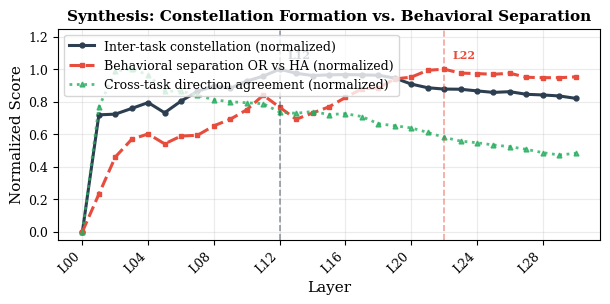

✓ Fig6 saved: fig13a_06_synthesis.pdf/png

=== FIGURE DATA (Fig 6: synthesis) ===
  Constellation peak: L12
  Behavioral separation peak: L22
  Gap between peaks: 10 layers


In [19]:
# ── Figure 6 — Synthesis (ACL single-column) ─────────────────
def norm01(arr):
    a = np.array(arr, dtype=float)
    lo, hi = np.nanmin(a), np.nanmax(a)
    return (a - lo) / (hi - lo + 1e-8)

sil_norm = norm01(sil_vals)
beh_norm = norm01(beh_vals)
dir_norm = norm01(mean_cross_sim) if any(not np.isnan(v) for v in mean_cross_sim) else [np.nan]*N_LAYERS

fig, ax = plt.subplots(figsize=(7.0, 3.2))
plt.subplots_adjust(bottom=0.22)

xs = range(N_LAYERS)
ax.plot(xs, sil_norm, color='#2C3E50', lw=2.2, marker='o', ms=3.5,
        label='Inter-task constellation (normalized)')
ax.plot(xs, beh_norm, color='#E74C3C', lw=2.2, marker='s', ms=3.5, ls='--',
        label='Behavioral separation OR vs HA (normalized)')
ax.plot(xs, dir_norm, color='#27AE60', lw=2.0, marker='^', ms=3.5, ls=':',
        label='Cross-task direction agreement (normalized)', alpha=0.8)

for vals, color, name in [(sil_norm, '#2C3E50', 'Const.'), (beh_norm, '#E74C3C', 'Beh.')]:
    pk = int(np.nanargmax(vals))
    ax.axvline(pk, color=color, lw=1.2, ls='--', alpha=0.5)
    ax.annotate(f'L{pk:02d}', xy=(pk, vals[pk]), xytext=(pk + 0.5, min(vals[pk] + 0.07, 1.15)),
                fontsize=8, color=color, fontweight='bold')

xtick_pos = list(range(0, N_LAYERS, 4))
ax.set_xticks(xtick_pos)
ax.set_xticklabels([f'L{i:02d}' for i in xtick_pos], fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Layer', fontsize=11, labelpad=3)
ax.set_ylabel('Normalized Score', fontsize=11, labelpad=3)
ax.set_title('Synthesis: Constellation Formation vs. Behavioral Separation',
             fontsize=11, fontweight='bold', pad=6)
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(-0.05, 1.25)
ax.tick_params(labelsize=9)

plt.savefig('fig13a_06_synthesis.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig13a_06_synthesis.png', bbox_inches='tight', dpi=300)
plt.show()
print('✓ Fig6 saved: fig13a_06_synthesis.pdf/png')

pk_inter = int(np.nanargmax(sil_norm))
pk_beh   = int(np.nanargmax(beh_norm))
print()
print('=== FIGURE DATA (Fig 6: synthesis) ===')
print(f'  Constellation peak: L{pk_inter:02d}')
print(f'  Behavioral separation peak: L{pk_beh:02d}')
print(f'  Gap between peaks: {abs(pk_beh - pk_inter)} layers')
print('='*50)


In [20]:
# Full NB13a Summary — Printed Report
print()
print('=' * 72)
print('NB13a COMPLETE FINDINGS REPORT')
print('=' * 72)

pk_sep = int(np.argmax(sep_vals))
pk_sil = int(np.nanargmax(sil_vals))

print()
print('[1] CONSTELLATION FORMATION')
print(f'    Peak separation ratio : L{pk_sep:02d} = {sep_vals[pk_sep]:.3f}')
print(f'    Peak silhouette score : L{pk_sil:02d} = {sil_vals[pk_sil]:.3f}')
print(f'    Phase silhouette means: early={np.nanmean(sil_vals[:8]):.3f} | '
      f'mid={np.nanmean(sil_vals[8:20]):.3f} | late={np.nanmean(sil_vals[20:]):.3f}')
print(f'    Finding: Constellation formation window is L08-L19 (mid-layers).')

print()
print('[2] REFUSAL CRYSTALLIZATION (within-task)')
for task in ALL_TASKS:
    row = [cryst_sil.get((task, l), np.nan) for l in LAYER_NAMES]
    if np.all(np.isnan(row)):
        print(f'    {task:<22}: insufficient data')
    else:
        pk  = int(np.nanargmax(row))
        val = float(np.nanmax(row))
        print(f'    {task:<22}: peaks at L{pk:02d} = {val:.3f}')

print()
print('[3] ARDITI DIRECTION VALIDITY')
if mean_cross_sim and not all(np.isnan(mean_cross_sim)):
    for idx in [0, 8, 12, 20, 31]:
        if idx < len(mean_cross_sim):
            print(f'    L{idx:02d} mean cross-task sim : {mean_cross_sim[idx]:.3f}')
    pk_dir = int(np.nanargmax(mean_cross_sim))
    print(f'    Peak convergence       : L{pk_dir:02d} = {mean_cross_sim[pk_dir]:.3f}')
    print(f'    Constellation peak     : L{pk_sep:02d} = {sep_vals[pk_sep]:.3f}')
    gap = pk_dir - pk_sep
    if gap > 0:
        print(f'    Verdict: Direction convergence is {gap} layers AFTER constellation peak.')
        print(f'    Arditi captures the late final-pathway signal, missing the mid-layer task structure.')
    elif gap < 0:
        print(f'    Verdict: Direction converges {abs(gap)} layers BEFORE constellation peak.')
        print(f'    Refusal direction convergence is early; constellations carry orthogonal structure.')
    else:
        print(f'    Verdict: Both peak at L{pk_sep:02d}. Convergence and constellation formation co-occur.')

print()
print('[4] SAVED FIGURES')
for fname in ['fig1_umap_galaxy_grid.pdf', 'fig2_layer_profile_metrics.pdf',
              'fig3_crystallization_heatmap.pdf', 'fig4_centroid_distance_heatmaps.pdf',
              'fig5_direction_convergence.pdf', 'fig6_synthesis.pdf']:
    exists = 'OK' if os.path.exists(fname) else 'MISSING'
    print(f'    {fname:<45} [{exists}]')

print()
print('Next: NB13b — apply Arditi to our task data, measure consequences, present task-aware fix.')
print('=' * 72)


NB13a COMPLETE FINDINGS REPORT

[1] CONSTELLATION FORMATION
    Peak separation ratio : L01 = 2.380
    Peak silhouette score : L12 = 0.454
    Phase silhouette means: early=0.306 | mid=0.431 | late=0.391
    Finding: Constellation formation window is L08-L19 (mid-layers).

[2] REFUSAL CRYSTALLIZATION (within-task)
    cryptanalysis         : insufficient data
    rag_qa                : insufficient data
    rephrase              : peaks at L19 = 0.066
    sentiment_analysis    : peaks at L16 = 0.076
    translate             : peaks at L17 = 0.081

[3] ARDITI DIRECTION VALIDITY
    L00 mean cross-task sim : 0.000
    L08 mean cross-task sim : 0.724
    L12 mean cross-task sim : 0.656
    L20 mean cross-task sim : 0.569
    Peak convergence       : L03 = 0.891
    Constellation peak     : L01 = 2.380
    Verdict: Direction convergence is 2 layers AFTER constellation peak.
    Arditi captures the late final-pathway signal, missing the mid-layer task structure.

[4] SAVED FIGURES
    f

In [21]:
# Save PDFs to Google Drive
os.makedirs('/content/drive/MyDrive/Colab Notebooks/SteeringFail/nb13a_figs', exist_ok=True)
for fname in ['fig1_umap_galaxy_grid.pdf', 'fig2_layer_profile_metrics.pdf',
              'fig3_crystallization_heatmap.pdf', 'fig4_centroid_distance_heatmaps.pdf',
              'fig5_direction_convergence.pdf', 'fig6_synthesis.pdf']:
    if os.path.exists(fname):
        !cp "{fname}" "/content/drive/MyDrive/Colab Notebooks/SteeringFail/nb13a_figs/"
        print(f'Saved to Drive: {fname}')
    else:
        print(f'Not found (run earlier cells first): {fname}')

Not found (run earlier cells first): fig1_umap_galaxy_grid.pdf
Not found (run earlier cells first): fig2_layer_profile_metrics.pdf
Not found (run earlier cells first): fig3_crystallization_heatmap.pdf
Saved to Drive: fig4_centroid_distance_heatmaps.pdf
Not found (run earlier cells first): fig5_direction_convergence.pdf
Not found (run earlier cells first): fig6_synthesis.pdf
